In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_modelo = pd.read_csv(
    "../Datos/df_modelo_vulnerabilidad.csv"
)

df_modelo.shape

(222305, 22)

In [3]:
df_modelo.head()

,PERIODO,COLE_AREA_UBICACION,COLE_BILINGUE,COLE_GENERO,COLE_JORNADA,COLE_MCPIO_UBICACION,ESTU_GENERO,ESTU_PAIS_RESIDE,FAMI_CUARTOSHOGAR,FAMI_EDUCACIONMADRE,...,FAMI_PERSONASHOGAR,FAMI_TIENEAUTOMOVIL,FAMI_TIENECOMPUTADOR,FAMI_TIENEINTERNET,FAMI_TIENELAVADORA,PUNT_GLOBAL,EDAD,SCORE_CONTEXTO,CONTEXTO_FAVORABLE,RIESGO_OCULTO
0,20224,URBANO,N,MIXTO,UNICA,GRANADA,F,COLOMBIA,Dos,Ninguno,...,5 a 6,No,No,No,No,196.0,18.0,0,0,0
1,20224,URBANO,N,MIXTO,SABATINA,CHOACHÍ,M,COLOMBIA,Tres,Secundaria (Bachillerato) incompleta,...,3 a 4,No,Si,Si,Si,258.0,17.0,2,0,0
2,20224,URBANO,N,MIXTO,COMPLETA,SOACHA,M,COLOMBIA,Tres,Técnica o tecnológica completa,...,3 a 4,No,Si,Si,Si,285.0,18.0,3,0,0
3,20224,URBANO,N,MIXTO,COMPLETA,SOACHA,F,COLOMBIA,Tres,Secundaria (Bachillerato) completa,...,3 a 4,No,Si,Si,Si,302.0,16.0,2,0,0
4,20224,RURAL,N,MIXTO,SABATINA,SASAIMA,M,COLOMBIA,Dos,Técnica o tecnológica completa,...,1 a 2,No,No,Si,Si,241.0,16.0,2,0,0


ELIMINAR LEAKAGE

In [4]:
df_modelo = df_modelo.drop(
    columns=[
        "PUNT_GLOBAL",
        "CONTEXTO_FAVORABLE",
        "SCORE_CONTEXTO"
    ]
)

SEPRAR X Y Y, TARGET

In [5]:
X = df_modelo.drop(
    columns=["RIESGO_OCULTO"]
)

y = df_modelo["RIESGO_OCULTO"]

y.value_counts()

RIESGO_OCULTO
0    215451
1      6854
Name: count, dtype: int64

In [6]:
encoder = LabelEncoder()

for col in X.columns:
    
    if X[col].dtype == "object":
        
        X[col] = encoder.fit_transform(
            X[col].astype(str)
        )

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Las variables predictoras se escalan utilizando StandardScaler con el fin de estandarizar sus valores y evitar que variables con magnitudes mayores dominen el proceso de entrenamiento. Esto resulta especialmente importante en redes neuronales, ya que facilita la convergencia y mejora la estabilidad del aprendizaje.

In [8]:
scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)

Debido a que la variable objetivo presenta un desbalance entre las clases, se calculan pesos para cada categoría mediante class_weight. De esta forma, el modelo asigna una mayor importancia a la clase minoritaria durante el entrenamiento, reduciendo el sesgo hacia la clase mayoritaria.

In [9]:
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {
    0: weights[0],
    1: weights[1]
}

print(class_weights)

{0: np.float64(0.5159055702856215), 1: np.float64(16.217763997811417)}


Debido al desbalance presente en la variable objetivo, se calculan pesos para cada clase utilizando compute_class_weight. Los resultados muestran que la clase minoritaria (RIESGO_OCULTO = 1) recibe un peso aproximadamente 31 veces mayor que la clase mayoritaria, lo que implica que el modelo penalizará con mayor intensidad los errores asociados a estudiantes vulnerables. Esto permite reducir el sesgo hacia la clase dominante y mejorar la capacidad del modelo para identificar casos de interés.

Se construyó una red neuronal multicapa (MLP) compuesta por dos capas ocultas de 32 y 16 neuronas respectivamente, utilizando funciones de activación ReLU para capturar relaciones no lineales entre las variables predictoras. La capa de salida está conformada por una única neurona con función sigmoide, adecuada para clasificación binaria. El modelo fue entrenado durante 10 épocas con un tamaño de lote (batch size) de 32 observaciones, empleando el optimizador Adam y la función de pérdida binary crossentropy. Adicionalmente, se incorporaron pesos de clase para mitigar el desbalance presente en la variable objetivo.

Capas ocultas: 2
Neuronas: 32 y 16
Épocas: 10
Batch size: 32
Activación ocultas: ReLU
Salida: Sigmoid
Optimizador: Adam
Loss: Binary Crossentropy
Balanceo: class_weight

In [10]:
model = Sequential()

model.add(
    Dense(
        32,
        activation='relu',
        input_shape=(
            X_train.shape[1],
        )
    )
)

model.add(
    Dense(
        16,
        activation='relu'
    )
)

model.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\dfgal\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,153 (4.50 KB)

 Trainable params: 1,153 (4.50 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights
)

Epoch 1/10
4447/4447 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.7289 - loss: 0.4274 - val_accuracy: 0.7921 - val_loss: 0.3870
Epoch 2/10
4447/4447 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.7800 - loss: 0.3639 - val_accuracy: 0.8001 - val_loss: 0.3555
Epoch 3/10
4447/4447 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.7852 - loss: 0.3426 - val_accuracy: 0.8100 - val_loss: 0.3402
Epoch 4/10
4447/4447 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.7901 - loss: 0.3269 - val_accuracy: 0.7936 - val_loss: 0.3754
Epoch 5/10
4447/4447 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.7914 - loss: 0.3175 - val_accuracy: 0.7892 - val_loss: 0.3673
Epoch 6/10
4447/4447 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.7915 - loss: 0.3139 - val_accuracy: 0.7912 - val_loss: 0.3772
Epoch 7/10
4447/4447 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.7919 - loss: 0.3091 - val_accuracy: 0.7908 - val_loss: 0.3673
Epoch 8/10
4447/4447 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.7931 - loss: 0.3054

In [12]:
y_pred = model.predict(
    X_test
)

y_pred = (
    y_pred > 0.5
).astype(int)

1390/1390 ━━━━━━━━━━━━━━━━━━━━ 1s 574us/step


In [13]:
print(
classification_report(
    y_test,
    y_pred
)
)

              precision    recall  f1-score   support

           0       1.00      0.77      0.87     43090
           1       0.12      0.97      0.21      1371

    accuracy                           0.78     44461
   macro avg       0.56      0.87      0.54     44461
weighted avg       0.97      0.78      0.85     44461



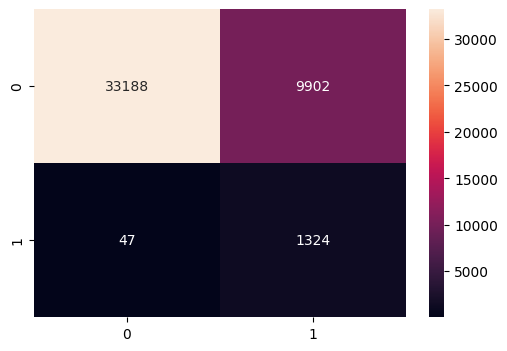

In [14]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(
figsize=(6,4)
)

sns.heatmap(
cm,
annot=True,
fmt='d'
)

plt.show()

El modelo logró identificar la mayoría de los casos pertenecientes a la clase minoritaria, alcanzando un recall de 0.97 para la categoría de riesgo oculto. Esto evidencia una alta sensibilidad para detectar estudiantes vulnerables. Sin embargo, la precisión obtenida fue reducida (0.12), indicando la presencia de falsos positivos. Este comportamiento puede atribuirse al fuerte desbalance de la variable objetivo y al uso de pesos de clase, los cuales priorizan la detección de casos vulnerables sobre la reducción de errores de clasificación.

MODELO 2

Capas ocultas: 2
Neuronas: 64 y 32
Épocas: 10
Batch size: 32
Activación capas ocultas: ReLU
Activación salida: Sigmoid
Optimizador: Adam
Función de pérdida: Binary Crossentropy
Balanceo: class_weight

In [15]:
model1 = Sequential()

model1.add(
    Dense(
        64,
        activation='relu',
        input_shape=(
            X_train.shape[1],
        )
    )
)

model1.add(
    Dense(
        32,
        activation='relu'
    )
)

model1.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

model1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

c:\Users\dfgal\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
Con el fin de evaluar el efecto de la arquitectura sobre el desempeño del modelo, se construyó una segunda configuración incrementando el número de neuronas en las capas ocultas de 32–16 a 64–32, manteniendo constantes los demás hiperparámetros. Esto permite analizar si una mayor capacidad de representación mejora la identificación de estudiantes vulnerables.

In [16]:
history1 = model1.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights
)

Epoch 1/10
4447/4447 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.7504 - loss: 0.4093 - val_accuracy: 0.8031 - val_loss: 0.3739
Epoch 2/10
4447/4447 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.7868 - loss: 0.3577 - val_accuracy: 0.8117 - val_loss: 0.3709
Epoch 3/10
4447/4447 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.7933 - loss: 0.3393 - val_accuracy: 0.7795 - val_loss: 0.4107
Epoch 4/10
4447/4447 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.7961 - loss: 0.3245 - val_accuracy: 0.8077 - val_loss: 0.3501
Epoch 5/10
4447/4447 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.7975 - loss: 0.3190 - val_accuracy: 0.7987 - val_loss: 0.3672
Epoch 6/10
4447/4447 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.7984 - loss: 0.3119 - val_accuracy: 0.7854 - val_loss: 0.3872
Epoch 7/10
4447/4447 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.7990 - loss: 0.3059 - val_accuracy: 0.8076 - val_loss: 0.3374
Epoch 8/10
4447/4447 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.8023 - loss: 0

In [17]:
y_pred1 = model1.predict(X_test)

y_pred1 = (
    y_pred1 > 0.5
).astype(int)

1390/1390 ━━━━━━━━━━━━━━━━━━━━ 1s 662us/step


In [18]:
print(
    classification_report(
        y_test,
        y_pred1
    )
)

              precision    recall  f1-score   support

           0       1.00      0.79      0.88     43090
           1       0.13      0.93      0.22      1371

    accuracy                           0.80     44461
   macro avg       0.56      0.86      0.55     44461
weighted avg       0.97      0.80      0.86     44461



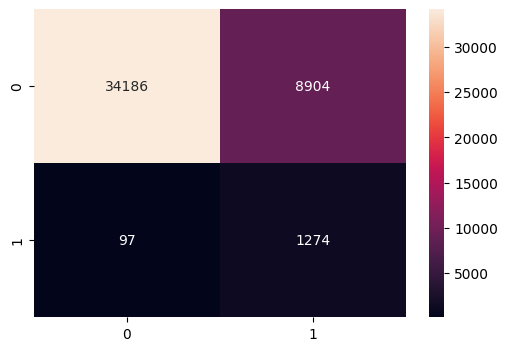

In [19]:
cm1 = confusion_matrix(
    y_test,
    y_pred1
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm1,
    annot=True,
    fmt='d'
)

plt.show()

In [20]:
df_modelo.head()

,PERIODO,COLE_AREA_UBICACION,COLE_BILINGUE,COLE_GENERO,COLE_JORNADA,COLE_MCPIO_UBICACION,ESTU_GENERO,ESTU_PAIS_RESIDE,FAMI_CUARTOSHOGAR,FAMI_EDUCACIONMADRE,FAMI_EDUCACIONPADRE,FAMI_ESTRATOVIVIENDA,FAMI_PERSONASHOGAR,FAMI_TIENEAUTOMOVIL,FAMI_TIENECOMPUTADOR,FAMI_TIENEINTERNET,FAMI_TIENELAVADORA,EDAD,RIESGO_OCULTO
0,20224,URBANO,N,MIXTO,UNICA,GRANADA,F,COLOMBIA,Dos,Ninguno,Ninguno,Estrato 1,5 a 6,No,No,No,No,18.0,0
1,20224,URBANO,N,MIXTO,SABATINA,CHOACHÍ,M,COLOMBIA,Tres,Secundaria (Bachillerato) incompleta,Primaria completa,Estrato 1,3 a 4,No,Si,Si,Si,17.0,0
2,20224,URBANO,N,MIXTO,COMPLETA,SOACHA,M,COLOMBIA,Tres,Técnica o tecnológica completa,Secundaria (Bachillerato) completa,Estrato 2,3 a 4,No,Si,Si,Si,18.0,0
3,20224,URBANO,N,MIXTO,COMPLETA,SOACHA,F,COLOMBIA,Tres,Secundaria (Bachillerato) completa,Secundaria (Bachillerato) completa,Estrato 2,3 a 4,No,Si,Si,Si,16.0,0
4,20224,RURAL,N,MIXTO,SABATINA,SASAIMA,M,COLOMBIA,Dos,Técnica o tecnológica completa,No Aplica,Estrato 2,1 a 2,No,No,Si,Si,16.0,0


Como estaba entrenando el modelo con todas las variables pre-seleccionadoas, ahora decidí quitar las que consideraba no importantes para ver si mejora el ruido y los resultados del modelo

Tras evaluar el modelo base, se realizó una etapa de optimización mediante selección conceptual de variables. Se eliminaron las variables PERIODO, ESTU_PAIS_RESIDE y COLE_MCPIO_UBICACION debido a su bajo aporte esperado frente a la pregunta de investigación. En particular, se excluyó la variable temporal PERIODO al no analizar efectos longitudinales, ESTU_PAIS_RESIDE por su limitada variabilidad dentro de la muestra y COLE_MCPIO_UBICACION por su alta cardinalidad y potencial incorporación de ruido al modelo.

In [21]:
df_modelo_opt = df_modelo.drop(
    columns=[
        "PERIODO",
        "ESTU_PAIS_RESIDE",
        "COLE_MCPIO_UBICACION"
    ]
)

In [22]:
X = df_modelo_opt.drop(
    columns=["RIESGO_OCULTO"]
)

y = df_modelo_opt["RIESGO_OCULTO"]

In [23]:
X = pd.get_dummies(
    X,
    drop_first=True
)

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Las variables predictoras fueron estandarizadas mediante StandardScaler con el fin de homogeneizar sus escalas y evitar que variables con magnitudes mayores dominen el proceso de aprendizaje. Este procedimiento resulta especialmente importante en redes neuronales, dado que contribuye a mejorar la estabilidad numérica y la convergencia del entrenamiento.

In [25]:
scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)

Debido al desbalance presente en la variable objetivo, se calcularon pesos para cada clase utilizando compute_class_weight. Este procedimiento incrementa la penalización asociada a errores sobre la clase minoritaria (RIESGO_OCULTO = 1), permitiendo reducir el sesgo hacia la clase mayoritaria y mejorar la capacidad del modelo para detectar estudiantes vulnerables.

In [26]:
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {
    0: weights[0],
    1: weights[1]
}

print(class_weights)

{0: np.float64(0.5159055702856215), 1: np.float64(16.217763997811417)}


Los pesos obtenidos evidencian el desbalance entre clases, asignando una mayor importancia relativa a la clase minoritaria durante el entrenamiento. En el modelo inicial, la clase de riesgo recibió una penalización aproximada 31 veces superior respecto a la clase dominante.

El modelo base optimizado mantiene la arquitectura original de la red neuronal, compuesta por dos capas ocultas con 32 y 16 neuronas respectivamente. Esta configuración se entrena sobre el conjunto de variables seleccionado tras la etapa de optimización conceptual, buscando evaluar el efecto de la reducción de ruido sobre el desempeño predictivo. Se conservaron los demás hiperparámetros del modelo: entrenamiento durante 10 épocas, batch size de 32 observaciones, optimizador Adam, función de pérdida binary crossentropy y balanceo mediante pesos de clase.

In [27]:
# ======================================================
# MODELO 2 - BASE OPTIMIZADO (32 - 16)
# ======================================================

model_base = Sequential()

model_base.add(
    Dense(
        32,
        activation='relu',
        input_shape=(X_train.shape[1],)
    )
)

model_base.add(
    Dense(
        16,
        activation='relu'
    )
)

model_base.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

model_base.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_base = model_base.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights
)

Epoch 1/10


c:\Users\dfgal\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4447/4447 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.7907 - loss: 0.3318 - val_accuracy: 0.8268 - val_loss: 0.3066
Epoch 2/10
4447/4447 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.8298 - loss: 0.2536 - val_accuracy: 0.8119 - val_loss: 0.3371
Epoch 3/10
4447/4447 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.8337 - loss: 0.2443 - val_accuracy: 0.8279 - val_loss: 0.3234
Epoch 4/10
4447/4447 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.8374 - loss: 0.2429 - val_accuracy: 0.8340 - val_loss: 0.3079
Epoch 5/10
4447/4447 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.8384 - loss: 0.2397 - val_accuracy: 0.8413 - val_loss: 0.3021
Epoch 6/10
4447/4447 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.8411 - loss: 0.2379 - val_accuracy: 0.8384 - val_loss: 0.3022
Epoch 7/10
4447/4447 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.8426 - loss: 0.2376 - val_accuracy: 0.8368 - val_loss: 0.2997
Epoch 8/10
4447/4447 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.8436 - loss: 0.2358 - val

Una vez finalizado el entrenamiento, el modelo fue evaluado sobre el conjunto de prueba con el objetivo de analizar el efecto de la selección de variables respecto al modelo inicial.

1390/1390 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
              precision    recall  f1-score   support

           0       1.00      0.83      0.91     43090
           1       0.15      0.95      0.26      1371

    accuracy                           0.84     44461
   macro avg       0.58      0.89      0.59     44461
weighted avg       0.97      0.84      0.89     44461



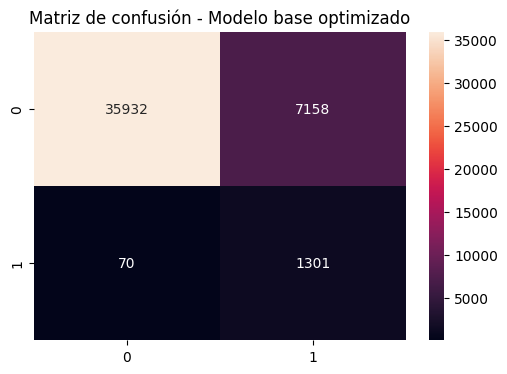

In [28]:
# ======================================================
# EVALUACIÓN MODELO 2
# ======================================================

y_pred_base = (
    model_base.predict(X_test) > 0.5
).astype(int)

print(
    classification_report(
        y_test,
        y_pred_base
    )
)

cm_base = confusion_matrix(
    y_test,
    y_pred_base
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_base,
    annot=True,
    fmt='d'
)

plt.title(
    "Matriz de confusión - Modelo base optimizado"
)

plt.show()

El modelo final optimizado incrementa la capacidad de representación de la red neuronal aumentando el número de neuronas en las capas ocultas a 64 y 32 respectivamente. Se mantuvieron constantes los demás hiperparámetros con el fin de evaluar exclusivamente el efecto de una arquitectura más compleja sobre el desempeño del modelo.

In [29]:
# ======================================================
# MODELO 3 - FINAL OPTIMIZADO (64 - 32)
# ======================================================

model_opt = Sequential()

model_opt.add(
    Dense(
        64,
        activation='relu',
        input_shape=(X_train.shape[1],)
    )
)

model_opt.add(
    Dense(
        32,
        activation='relu'
    )
)

model_opt.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

model_opt.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_opt = model_opt.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights
)

c:\Users\dfgal\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
4447/4447 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - accuracy: 0.8008 - loss: 0.3198 - val_accuracy: 0.8311 - val_loss: 0.3165
Epoch 2/10
4447/4447 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.8322 - loss: 0.2514 - val_accuracy: 0.8402 - val_loss: 0.2712
Epoch 3/10
4447/4447 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.8360 - loss: 0.2432 - val_accuracy: 0.8424 - val_loss: 0.2927
Epoch 4/10
4447/4447 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.8390 - loss: 0.2400 - val_accuracy: 0.8340 - val_loss: 0.3124
Epoch 5/10
4447/4447 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.8405 - loss: 0.2371 - val_accuracy: 0.8399 - val_loss: 0.3061
Epoch 6/10
4447/4447 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.8437 - loss: 0.2332 - val_accuracy: 0.8442 - val_loss: 0.2880
Epoch 7/10
4447/4447 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.8432 - loss: 0.2323 - val_accuracy: 0.8439 - val_loss: 0.2943
Epoch 8/10
4447/4447 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.8440 - loss: 0.23

El modelo final fue evaluado sobre el conjunto de prueba con el propósito de comparar su desempeño respecto a las configuraciones anteriores y seleccionar la arquitectura con mejor capacidad predictiva.

1390/1390 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
              precision    recall  f1-score   support

           0       1.00      0.83      0.91     43090
           1       0.15      0.95      0.26      1371

    accuracy                           0.84     44461
   macro avg       0.58      0.89      0.59     44461
weighted avg       0.97      0.84      0.89     44461



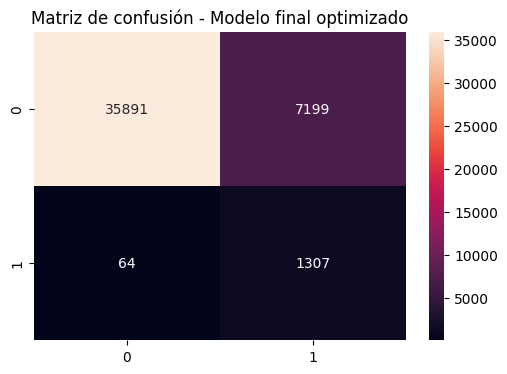

In [30]:
# ======================================================
# EVALUACIÓN MODELO 3
# ======================================================

y_pred_opt = (
    model_opt.predict(X_test) > 0.5
).astype(int)

print(
    classification_report(
        y_test,
        y_pred_opt
    )
)

cm_opt = confusion_matrix(
    y_test,
    y_pred_opt
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_opt,
    annot=True,
    fmt='d'
)

plt.title(
    "Matriz de confusión - Modelo final optimizado"
)

plt.show()

Se analizaron las curvas de entrenamiento y validación del modelo seleccionado con el fin de evaluar el comportamiento del aprendizaje e identificar posibles fenómenos de sobreajuste o subajuste.

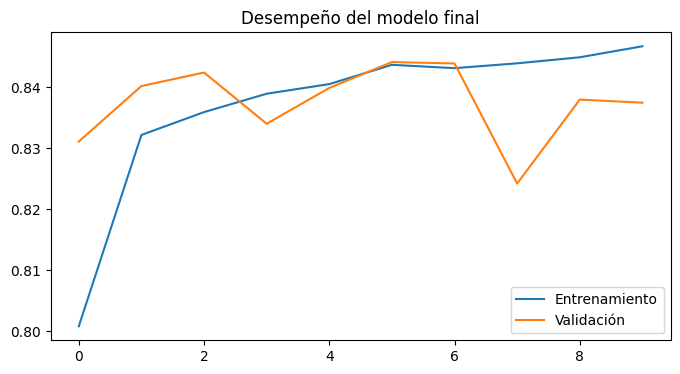

In [31]:
plt.figure(figsize=(8,4))

plt.plot(
    history_opt.history["accuracy"],
    label="Entrenamiento"
)

plt.plot(
    history_opt.history["val_accuracy"],
    label="Validación"
)

plt.legend()

plt.title(
    "Desempeño del modelo final"
)

plt.show()

La ampliación de la arquitectura de la red neuronal no produjo mejoras significativas sobre el desempeño predictivo. Los indicadores de precisión, recall y F1-score permanecieron prácticamente constantes respecto al modelo base optimizado, sugiriendo que el incremento en la complejidad del modelo no aporta beneficios adicionales para el problema planteado. En consecuencia, se selecciona el modelo base optimizado (32–16) por presentar un desempeño equivalente con una arquitectura más simple.

In [33]:
import os

os.makedirs(
    "./Resultados",
    exist_ok=True
)

model_base.save(
    "./Resultados/modelo_preg1_final.keras"
)

import pickle

with open(
    "./Resultados/scaler_preg1.pkl",
    "wb"
) as f:

    pickle.dump(
        scaler,
        f
    )

In [34]:
df_modelo_opt.to_csv(
    "./Resultados/df_modelo_preg3.csv",
    index=False
)